## 1. Load features and inspect per bearing
This cell loads time domain features for the 2nd test dataset.
One row is one measurement in time.
Each table shows the first 5 rows for one bearing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features import extract_features

DATA_DIR = 'data/raw/2nd_test/'
print(f"Loading raw files from {DATA_DIR}...", flush=True)
df = extract_features(DATA_DIR)
print(f"Extraction done: {df.shape[0]} rows x {df.shape[1]} columns", flush=True)
for i in [1, 2, 3, 4]:
    print(f"=== Bearing {i} ===")
    display(df[[c for c in df.columns if f'Bearing_{i}_' in c]].head())

Loading raw files from data/raw/2nd_test/...


Extraction done: 984 rows x 36 columns


=== Bearing 1 ===


,Bearing_1_RMS,Bearing_1_Kurtosis,Bearing_1_CrestFactor,Bearing_1_Peak,Bearing_1_Skewness,Bearing_1_Std,Bearing_1_SpecCentroid,Bearing_1_HighFreqRatio,Bearing_1_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.074179,0.628763,6.120331,0.454,0.083993,0.073475,3070.567759,0.153912,0.165731
2004-02-12 10:42:39,0.075382,0.648291,5.147086,0.388,0.052142,0.075338,3166.128408,0.163273,0.110776
2004-02-12 10:52:39,0.076230,0.513475,6.598472,0.503,0.032808,0.076189,3100.300247,0.149599,0.098292
2004-02-12 11:02:39,0.078724,1.157953,7.723217,0.608,0.041486,0.078691,3109.602997,0.138141,0.098743
2004-02-12 11:12:39,0.078474,0.603177,4.982524,0.391,0.028224,0.078437,3120.492498,0.141261,0.082650


=== Bearing 2 ===


,Bearing_2_RMS,Bearing_2_Kurtosis,Bearing_2_CrestFactor,Bearing_2_Peak,Bearing_2_Skewness,Bearing_2_Std,Bearing_2_SpecCentroid,Bearing_2_HighFreqRatio,Bearing_2_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.090944,0.506801,5.640841,0.513,0.126915,0.090053,3420.656160,0.266086,0.187006
2004-02-12 10:42:39,0.093419,0.253014,5.148852,0.481,0.070088,0.093384,3449.468883,0.275132,0.135018
2004-02-12 10:52:39,0.093718,0.310789,5.367171,0.503,0.096583,0.093703,3362.270029,0.260242,0.131032
2004-02-12 11:02:39,0.092947,0.235341,6.121762,0.569,0.105834,0.092916,3354.315540,0.256808,0.124036
2004-02-12 11:12:39,0.095348,0.226309,5.097120,0.486,0.097966,0.095335,3378.423624,0.261757,0.105475


=== Bearing 3 ===


,Bearing_3_RMS,Bearing_3_Kurtosis,Bearing_3_CrestFactor,Bearing_3_Peak,Bearing_3_Skewness,Bearing_3_Std,Bearing_3_SpecCentroid,Bearing_3_HighFreqRatio,Bearing_3_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.109404,3.213075,9.350652,1.023,0.204840,0.108434,4407.420328,0.453572,0.031031
2004-02-12 10:42:39,0.109817,1.395250,6.847735,0.752,-0.023854,0.109790,4163.041302,0.393622,0.022707
2004-02-12 10:52:39,0.109861,2.639948,8.492546,0.933,0.056561,0.109849,4309.493367,0.433683,0.022279
2004-02-12 11:02:39,0.110667,2.682779,9.180734,1.016,0.033550,0.110622,4304.471588,0.425780,0.020553
2004-02-12 11:12:39,0.107506,1.578395,7.171719,0.771,-0.002892,0.107499,4238.825438,0.404589,0.020393


=== Bearing 4 ===


,Bearing_4_RMS,Bearing_4_Kurtosis,Bearing_4_CrestFactor,Bearing_4_Peak,Bearing_4_Skewness,Bearing_4_Std,Bearing_4_SpecCentroid,Bearing_4_HighFreqRatio,Bearing_4_SpecPeak
Time,,,,,,,,,
2004-02-12 10:32:39,0.054103,0.065959,4.879539,0.264,-0.022080,0.053166,2856.063387,0.109053,0.074725
2004-02-12 10:42:39,0.056101,0.107539,4.438435,0.249,0.001582,0.055973,3015.342733,0.114113,0.059438
2004-02-12 10:52:39,0.056145,0.257236,6.305078,0.354,0.070449,0.056037,2932.935641,0.104460,0.054992
2004-02-12 11:02:39,0.056807,0.806190,9.241749,0.525,-0.036327,0.056684,2933.044689,0.105296,0.052543
2004-02-12 11:12:39,0.056841,0.138954,4.292680,0.244,0.019008,0.056777,2940.181258,0.107327,0.046934


## 2. All features over the full timeline

One subplot per feature, all 4 bearings in each.
Flat and low means healthy. A sharp rise means the fault starts.

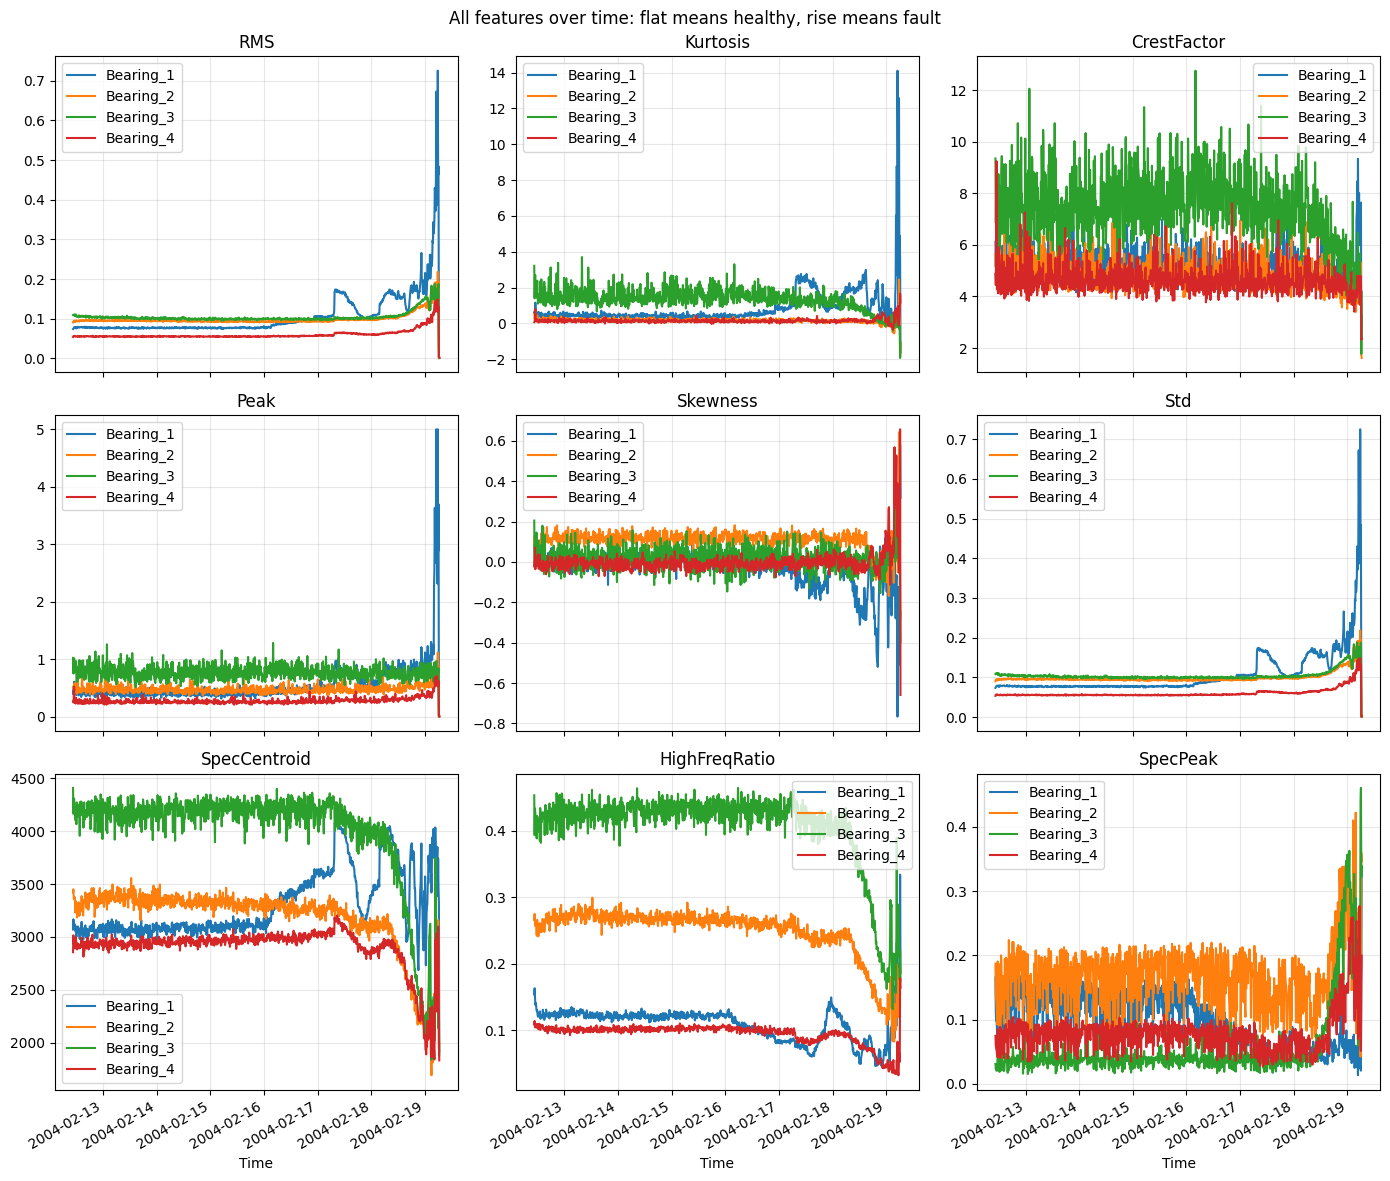

In [2]:
features = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
            'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True)
for ax, feat in zip(axes.flat, features):
    cols = [c for c in df.columns if c.endswith('_' + feat)]
    renamed = {c: c.replace('_' + feat, '') for c in cols}
    df[cols].rename(columns=renamed).plot(ax=ax)
    ax.set_title(feat)
    ax.grid(alpha=0.3)
plt.suptitle('All features over time: flat means healthy, rise means fault')
plt.tight_layout()
plt.show()

## 3. Fault localization: which bearing fails

Compare late against early values per bearing and per feature, no boundary needed.
A healthy channel stays near growth 1. The failed bearing grows on several
independent features at once. Skewness is left out, its healthy baseline sits
near zero so ratios explode.

### How the verdict is computed

1. Take the first 100 rows as the early reference and the last 100 rows as
   the late state.
2. For each bearing and each of RMS, Kurtosis, Peak and Std, divide late
   mean by early mean. That is the growth ratio.
3. Average the four growth ratios per bearing (CrestFactor and Skewness are
   excluded - see note below).
4. The bearing with the highest average growth ratio is printed as faulty.
   Full code lives in `identify_faulty_bearing` in `src/evaluation.py`.

In [3]:
from src.evaluation import identify_faulty_bearing

result = identify_faulty_bearing(df)
display(result['summary'])
print(f"Faulty bearing: {result['faulty_bearing']}")

,rms_growth,kurtosis_growth,crest_factor_growth,peak_growth,std_growth
bearing,,,,,
Bearing_1,2.79,3.64,0.96,2.86,2.79
Bearing_2,1.38,0.06,0.83,1.16,1.38
Bearing_3,1.29,0.10,0.74,0.94,1.29
Bearing_4,1.56,1.51,0.91,1.42,1.56


Faulty bearing: Bearing_1


### Reading the table above

Row by row: RMS and Std almost tripled on Bearing 1 only.
Peak nearly tripled on Bearing 1 only.
Kurtosis more than tripled on Bearing 1 only, the strongest single witness,
which fits an impulsive fault.
CrestFactor sinks below 1 on all bearings, the known late fault signature
where RMS has caught up with Peak.

**Why Skewness is excluded:** its healthy baseline sits near zero (for example
0.03), so late divided by early explodes into numbers like -14 that mean nothing.
It stays in the section 4 plots where its late swinging is visible directly.
For a ratio table it would only add noise, so the table keeps the five features
where division is meaningful.

How to read the values: every number is a quotient, late mean divided by early mean.
Near 1 means late looks like early, no change. Far from 1 means change.
Rows do not share one reading direction, each row has its own logic, so what
counts as bad differs per feature, as explained row by row below.
RMS and Std near 1.3 to 1.6 is normal drift, 2.79 means vibration energy
almost tripled. Peak near 1 means impacts unchanged, 2.86 means impacts
nearly tripled. Kurtosis near 0.1 to 1.5 is calm, 3.64 means heavy spiking
from impacts, the strongest single witness of an impulsive fault.
CrestFactor below 1 on all bearings is the late fault signature,
RMS has caught up with Peak everywhere.
The code prints the bearing with the highest average across the four growing
features, Bearing_1 at 3.02 against 1.51 for the runner up. No extra metric
is invented, the table holds only the five growth features and the winner
is read straight from them.
Documentation agrees (outer race), as confirmation only.

## 4. Faulty bearing in detail

The previous section identified Bearing 1.
Each feature has its own plot because features use different scales.
Look at which feature reacts first when the fault starts.

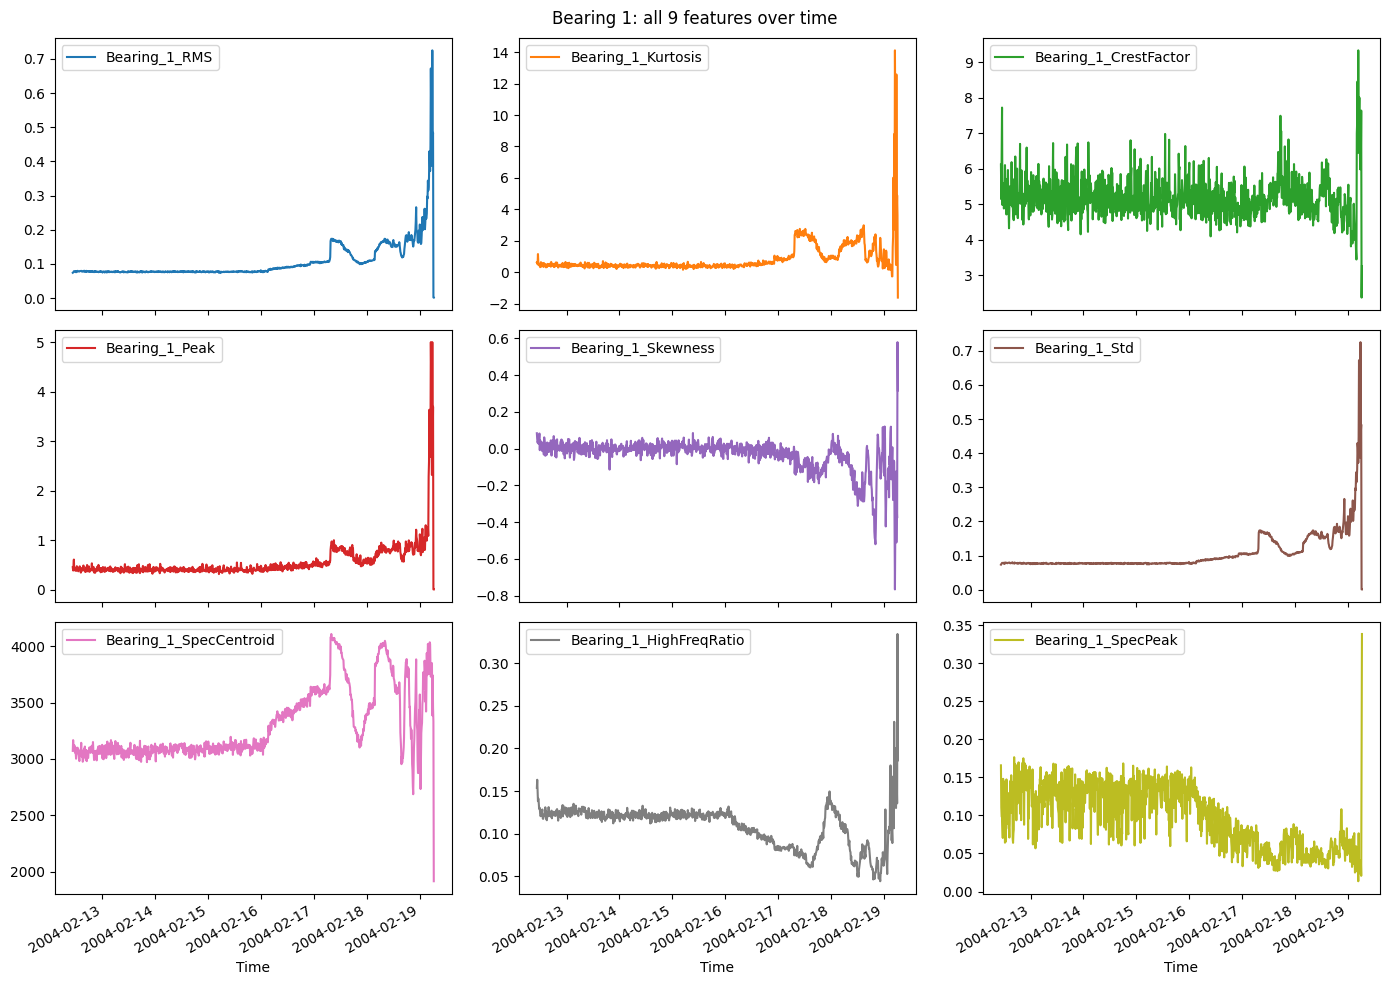

In [4]:
bearing1_cols = [c for c in df.columns if 'Bearing_1_' in c]
df[bearing1_cols].plot(figsize=(14, 10), subplots=True, layout=(3, 3))
plt.suptitle('Bearing 1: all 9 features over time')
plt.tight_layout()
plt.show()

## 5. Compare healthy boundary candidates
Try several boundary dates on Bearing_1_RMS and compare them side by side.
A good boundary keeps FPR low while giving enough healthy samples for training.
If the first alarm moves later when the boundary moves later, the boundary
has swallowed the start of the fault and is too late.

In [2]:
from src.evaluation import compare_boundaries

scores = df['Bearing_1_RMS']
candidates = [
    pd.Timestamp('2004-02-14 12:00:00'),
    pd.Timestamp('2004-02-14 18:00:00'),
    pd.Timestamp('2004-02-15 00:00:00'),
    pd.Timestamp('2004-02-15 06:00:00'),
    pd.Timestamp('2004-02-15 12:00:00'),
    pd.Timestamp('2004-02-15 18:00:00'),
    pd.Timestamp('2004-02-15 21:00:00'),
    pd.Timestamp('2004-02-16 00:00:00'),
    pd.Timestamp('2004-02-16 06:00:00'),
    pd.Timestamp('2004-02-16 12:00:00'),
    pd.Timestamp('2004-02-16 18:00:00'),
    pd.Timestamp('2004-02-17 00:00:00'),
]
compare_boundaries(scores, candidates)

,boundary,healthy_samples,threshold,first_alarm,fpr
0,2004-02-14 12:00:00,297,0.080486,2004-02-16 06:22:39,0.000000
1,2004-02-14 18:00:00,333,0.080461,2004-02-16 06:22:39,0.000000
2,2004-02-15 00:00:00,369,0.080421,2004-02-16 06:22:39,0.000000
3,2004-02-15 06:00:00,405,0.080460,2004-02-16 06:22:39,0.000000
4,2004-02-15 12:00:00,441,0.080361,2004-02-16 06:22:39,0.000000
5,2004-02-15 18:00:00,477,0.080398,2004-02-16 06:22:39,0.000000
6,2004-02-15 21:00:00,495,0.080385,2004-02-16 06:22:39,0.000000
7,2004-02-16 00:00:00,513,0.080459,2004-02-16 06:22:39,0.001949
8,2004-02-16 06:00:00,549,0.082455,2004-02-16 06:32:39,0.029144
9,2004-02-16 12:00:00,585,0.087362,2004-02-16 12:32:39,0.044444


### Reading the table above

- **Rows for 2004-02-14 12:00 through 2004-02-16 00:00** (6 candidates):
  threshold stays flat (~0.0804), first_alarm is identical every time
  (2004-02-16 06:22:39), FPR stays near zero. This means the fault has NOT
  started yet in this range - safe to use as "healthy" training data.
- **Rows from 2004-02-16 06:00 onward**: threshold keeps rising
  (0.082 -> 0.099), and first_alarm keeps shifting later (06:32 -> 12:32 ->
  18:32 -> next day 01:32). This is the signature of contamination: the
  fault has already begun, so including this period as "healthy" trains the
  model to treat early fault symptoms as normal, delaying detection.
- **Conclusion**: the widest safe boundary is 2004-02-16 00:00:00 - the last
  candidate before results start changing.

## 6. Decision: chosen healthy boundary

We choose 2004-02-16 00:00:00 (513 healthy samples) - the widest boundary
that still gives stable results, per the interpretation above.

In [2]:
HEALTHY_BOUNDARY = pd.Timestamp('2004-02-16')
print(f"Chosen healthy boundary: {HEALTHY_BOUNDARY}")

Chosen healthy boundary: 2004-02-16 00:00:00


## 7. Split into healthy / full dataset

Using the boundary chosen above. We further split the healthy period into
a training part (fits the model/scaler) and a validation part (sets the
threshold). This avoids computing the threshold on the same data the model
was fit on, which would bias it optimistically - per advisor feedback.

In [3]:
from src.preprocessing import split_healthy, scale_features, split_train_val

df_healthy = split_healthy(df, HEALTHY_BOUNDARY)
df_healthy_train, df_healthy_val = split_train_val(df_healthy, val_fraction=0.2)

print(f"Healthy total: {len(df_healthy)}")
print(f"Healthy train: {len(df_healthy_train)} ({df_healthy_train.index[0]} to {df_healthy_train.index[-1]})")
print(f"Healthy val:   {len(df_healthy_val)} ({df_healthy_val.index[0]} to {df_healthy_val.index[-1]})")

X_healthy_train, X_all, scaler = scale_features(df_healthy_train, df)
X_healthy_val = scaler.transform(df_healthy_val)
input_dim = X_healthy_train.shape[1]
n_spectral = len([c for c in df.columns if 'Spec' in c or 'High' in c])
print(f"Feature dimension: {input_dim} ({input_dim - n_spectral} time + {n_spectral} spectral)")

Healthy total: 513
Healthy train: 411 (2004-02-12 10:32:39 to 2004-02-15 06:52:39)
Healthy val:   102 (2004-02-15 07:02:39 to 2004-02-15 23:52:39)
Feature dimension: 36 (24 time + 12 spectral)


## 8. Classical models

Fit each detector on the TRAINING part of the healthy data only, then
compute its threshold from the held-out VALIDATION part (not seen during
fitting). Score the full timeline and compare first alarm and FPR.
Models train on all features together, time and spectral.

In [4]:
from src.classical_models import (
    fit_isolation_forest, score_isolation_forest,
    fit_one_class_svm, score_one_class_svm,
    fit_lof, score_lof,
    fit_pca, score_pca,
)
from src.evaluation import compute_threshold, first_confirmed_alarm, false_positive_rate
import numpy as np
from src.experiments import run_classical_suite

classical = [
    ('IsolationForest', fit_isolation_forest, score_isolation_forest),
    ('OneClassSVM', fit_one_class_svm, score_one_class_svm),
    ('LOF', fit_lof, score_lof),
    ('PCA', fit_pca, score_pca),
]

def _astr(a):
    return a.strftime('%Y-%m-%d %H:%M:%S') if a is not None else None

def _fmt(df):
    disp = df.copy()
    disp['first_alarm'] = disp['first_alarm'].apply(_astr)
    return disp.style.format({'val_mean': '{:.5f}', 'val_std': '{:.5f}',
        'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'})

train_end = df_healthy_train.index[-1]
val_end = df_healthy.index[-1]

print("Joint results on all 36 with spectral:")
classical_summary_df, classical_results = run_classical_suite(
    classical, X_healthy_train, X_all, X_healthy_val, df.index, train_end, val_end)
display(_fmt(classical_summary_df))

OLD6 = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std']
old_cols = [c for c in df.columns if any(c.endswith('_' + f) for f in OLD6)]
Xtr_old, Xa_old, sc_old = scale_features(df_healthy_train[old_cols], df[old_cols])
Xva_old = sc_old.transform(df_healthy_val[old_cols])
print("Joint results on old 24 time features:")
old_summary_df, old_results = run_classical_suite(
    classical, Xtr_old, Xa_old, Xva_old, df.index, train_end, val_end)
display(_fmt(old_summary_df))

print("Difference in first alarm (positive hours = 36 earlier):")
diff_rows = []
for name, _, _ in classical:
    a24 = old_results[name]['alarm']
    a36 = classical_results[name]['alarm']
    gain = None
    if a24 is not None and a36 is not None:
        gain = round((a24 - a36).total_seconds() / 3600, 1)
    diff_rows.append({'model': name, 'alarm_24': _astr(a24), 'alarm_36': _astr(a36),
                       'hours_earlier_36': gain,
                       'fpr_24': round(old_results[name]['fpr_val'], 4),
                       'fpr_36': round(classical_results[name]['fpr_val'], 4)})
display(pd.DataFrame(diff_rows))

Joint results on all 36 with spectral:


,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.43397,0.02645,0.51331,2004-02-17 01:32:39,0.0316,0.0000
1,LOF,1.06009,0.06935,1.26813,2004-02-16 06:22:39,0.0195,0.0196
2,OneClassSVM,-0.10735,0.09196,0.16852,2004-02-16 06:22:39,0.0000,0.0000
3,PCA,0.04238,0.02668,0.12244,2004-02-16 12:32:39,0.0122,0.0098


Joint results on old 24 time features:


,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,IsolationForest,0.43148,0.02951,0.51999,2004-02-17 10:22:39,0.0316,0.0000
1,LOF,1.07513,0.08476,1.32941,2004-02-16 06:22:39,0.0292,0.0098
2,OneClassSVM,-0.11021,0.08738,0.15192,2004-02-16 06:22:39,0.0000,0.0196
3,PCA,0.02465,0.01916,0.08212,2004-02-17 02:52:39,0.0292,0.0196


Difference in first alarm (positive hours = 36 earlier):


,model,alarm_24,alarm_36,hours_earlier_36,fpr_24,fpr_36
0,IsolationForest,2004-02-17 10:22:39,2004-02-17 01:32:39,8.8,0.0000,0.0000
1,OneClassSVM,2004-02-16 06:22:39,2004-02-16 06:22:39,0.0,0.0196,0.0000
2,LOF,2004-02-16 06:22:39,2004-02-16 06:22:39,0.0,0.0098,0.0196
3,PCA,2004-02-17 02:52:39,2004-02-16 12:32:39,14.3,0.0196,0.0098


### Healthy error histograms

Distribution of validation scores per model with the threshold line.
Shows the threshold sits at the edge of healthy behaviour, justifying
mean plus 3 sigma.

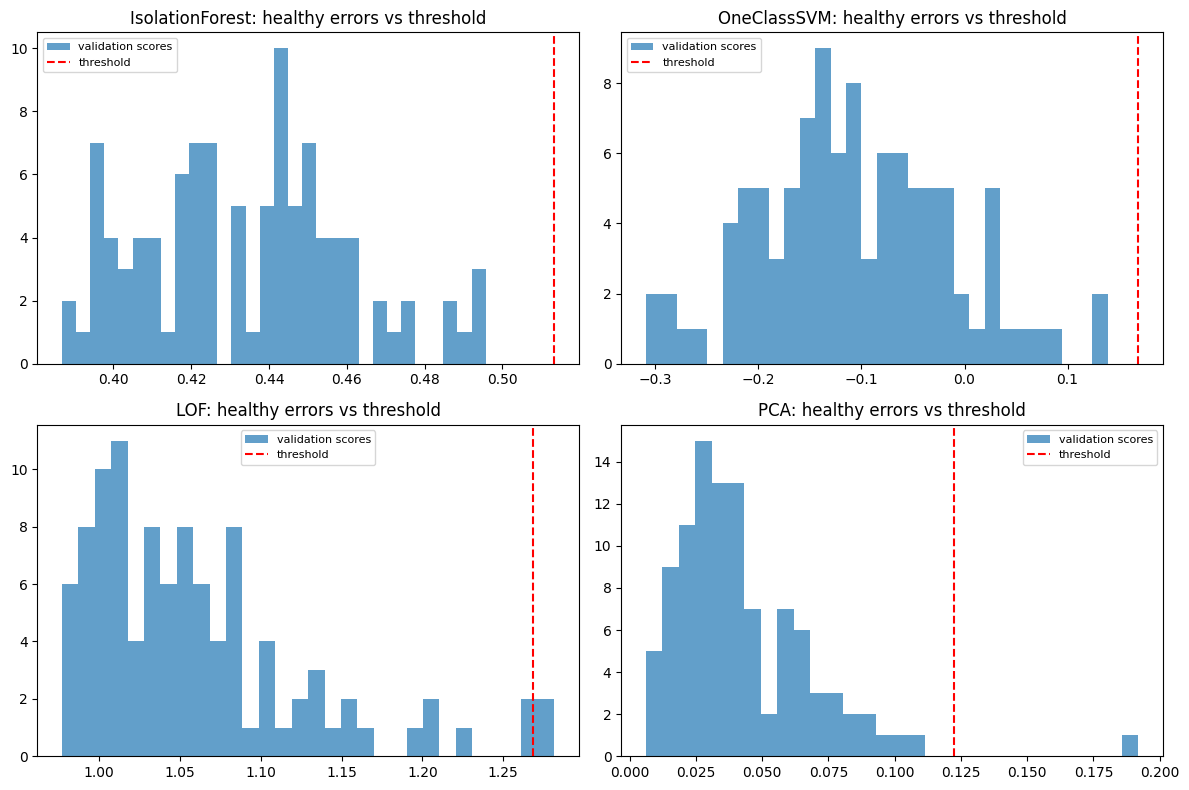

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name in zip(axes.flat, ['IsolationForest', 'OneClassSVM', 'LOF', 'PCA']):
    r = classical_results[name]
    ax.hist(r['val_scores'], bins=30, alpha=0.7, label='validation scores')
    ax.axvline(r['threshold'], color='red', linestyle='--', label='threshold')
    ax.set_title(f"{name}: healthy errors vs threshold")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

How to read these plots: each bar counts healthy validation samples by model
score (x = score, y = count). The red line is the threshold. Everything left
of it is quiet, everything right would alarm. The gap between the bulk and
the line is the safety margin: healthy almost never crosses (low FPR), while
fault scores reach far beyond it.

## 9. Joint vs separate training

Same four models on three kinds of input. all_24 is the original joint setup:
24 time features together, kept as the reference from before spectral features
existed. all_36 is the current joint setup: all 24 plus 12 spectral features
together. The rest are single feature types across all 4 bearings. Both joint
rows reuse the section 8 results, nothing is retrained for them. Shows whether
the combination beats any single feature on its own.

In [5]:
from src.evaluation import alarm_and_fpr

train_end = df_healthy_train.index[-1]
val_end = df_healthy.index[-1]

comparison = []
for name, _, _ in classical:
    r = old_results[name]
    comparison.append({'setup': 'all_24', 'model': name,
                       'alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': round(r['fpr_train'], 4), 'fpr_val': round(r['fpr_val'], 4)})
for name, _, _ in classical:
    r = classical_results[name]
    alarm, fpr_train, fpr_val = alarm_and_fpr(r['scores'], r['threshold'], train_end, val_end)
    comparison.append({'setup': 'all_36', 'model': name, 'alarm': alarm,
                       'fpr_train': fpr_train, 'fpr_val': fpr_val})

feature_types = ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std',
                   'SpecCentroid', 'HighFreqRatio', 'SpecPeak']
from src.experiments import compare_column_setups
groups = {f: [c for c in df.columns if c.endswith('_' + f)] for f in feature_types}
feat_df = compare_column_setups(classical, groups, df, df_healthy_train, df_healthy_val,
                                train_end, val_end, verbose=True)
comparison.extend(feat_df.to_dict('records'))

order = ['all_24', 'all_36'] + feature_types
comp_df = pd.DataFrame(comparison)
comp_df['setup'] = pd.Categorical(comp_df['setup'], categories=order, ordered=True)
comp_df = comp_df.sort_values(['setup', 'model']).reset_index(drop=True)
print("First confirmed alarm per setup and model (None = the model never alarmed):")
display(comp_df.pivot_table(index='setup', columns='model', values='alarm', aggfunc='first', observed=True))
print("False positive rate on VALIDATION per setup and model (primary, unseen data):")
display(comp_df.pivot_table(index='setup', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))
print("False positive rate on TRAIN per setup and model (sanity check, seen data):")
display(comp_df.pivot_table(index='setup', columns='model', values='fpr_train', aggfunc='first', observed=True).style.format('{:.4f}'))

--- RMS ---


--- Kurtosis ---


--- CrestFactor ---


--- Peak ---


--- Skewness ---


...

model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 02:52:39
all_36,2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 12:32:39
RMS,2004-02-17 05:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:52:39
Kurtosis,2004-02-17 09:42:39,2004-02-17 05:52:39,2004-02-17 01:32:39,2004-02-17 10:22:39
CrestFactor,NaN,2004-02-19 05:52:39,NaN,NaN
Peak,2004-02-17 10:42:39,2004-02-17 10:12:39,2004-02-17 10:12:39,2004-02-18 09:42:39
Skewness,2004-02-18 20:02:39,2004-02-17 20:42:39,2004-02-18 12:32:39,NaN
Std,2004-02-17 05:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 07:02:39
SpecCentroid,2004-02-17 21:42:39,2004-02-16 06:22:39,2004-02-16 06:32:39,2004-02-16 14:22:39


False positive rate on VALIDATION per setup and model (primary, unseen data):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,0.0000,0.0098,0.0196,0.0196
all_36,0.0000,0.0196,0.0000,0.0098
RMS,0.0000,0.0098,0.0098,0.0196
Kurtosis,0.0000,0.0196,0.0098,0.0294
CrestFactor,0.0000,0.0196,0.0196,0.0294
Peak,0.0000,0.0196,0.0098,0.0294
Skewness,0.0196,0.0294,0.0196,0.0098
Std,0.0000,0.0098,0.0098,0.0000
SpecCentroid,0.0000,0.0098,0.0098,0.0000


False positive rate on TRAIN per setup and model (sanity check, seen data):


model,IsolationForest,LOF,OneClassSVM,PCA
setup,,,,
all_24,0.0316,0.0292,0.0000,0.0292
all_36,0.0316,0.0195,0.0000,0.0122
RMS,0.0097,0.0170,0.0000,0.0073
Kurtosis,0.0341,0.0292,0.0000,0.0316
CrestFactor,0.0170,0.0268,0.0000,0.0243
Peak,0.0170,0.0316,0.0000,0.0268
Skewness,0.0146,0.0243,0.0000,0.0219
Std,0.0097,0.0195,0.0000,0.0438
SpecCentroid,0.0073,0.0049,0.0000,0.0000


### Reading the comparison above

No setup wins everywhere, the table must be read per model. SVM and LOF alarm
on 16.02 at 06:22 with all 36 features, and RMS and Std alone
match them to the minute, which confirms those two carry the fault signal
on their own. SpecCentroid matches LOF and trails SVM by 10 minutes.

Kurtosis alone alarms later than the joint setup on every model: about 23 hours
later for LOF, 19 for SVM, 8 for IsolationForest and 18 for PCA. Peak and
Skewness are consistently a day or more late in most cases.
CrestFactor alone mostly never alarms - three of four models return no
confirmed alarm at all, and the one exception (LOF, firing on 19.02) comes at
the very end of the recorded test.

With spectral features the IsolationForest story flipped: the joint setup at
01:32 now beats every single feature, best single RMS and Std at 05:52.
The combination is now strictly earlier here, not just more robust.

PCA behaves differently from the other three models when restricted to a
single feature type: with only 4 input columns, `n_components=0.95` keeps all 4
components, so nothing is compressed, validation reconstruction error collapses
close to zero and the resulting threshold becomes extremely tight. This makes the
per-feature PCA alarms harder to trust as a measure of feature quality
specifically - the model is reacting to a near-zero threshold rather than to
a clearly learned "normal" pattern. The joint 36-feature PCA result does not
have this problem, since 18 of 36 components are kept, and its
alarm (16.02 16:42) is the one PCA number used with confidence in this
comparison.

The FPR table tells a different story than the alarm table, and only the
validation column counts: fpr_val uses data the model never saw, fpr_train
is a sanity check. On fpr_val, IsolationForest is cleanest at 0.0000 in 8 of 11
setups. OneClassSVM sits at 0.0000 to 0.0196, yet it alarms earliest at 16.02
06:22 wherever the signal allows. The verdict splits: IsolationForest cries wolf
the least, OneClassSVM balances early alarms with low false rates, making it the
strongest single candidate if only one classical model had to be chosen.

The joint 36-feature setup is now the earliest choice for IsolationForest (01:32
against 05:52 best single) and tied for LOF and SVM (06:22). Only for PCA do
singles alarm earlier (RMS 07:52, Std 07:02 against joint 16:42), but per-feature
PCA thresholds are degenerate and machine dependent, so that comparison carries
no weight. Had someone tracked only CrestFactor or Skewness upfront, the fault
would be missed entirely or caught days late. The combination needs no lucky
pick, and now it also leads on speed wherever the numbers can be trusted.
Single-feature spectral alarms additionally wobble between identical runs
(SpecCentroid/PCA 07:12 one run, 14:22 the next) while joint rows reproduce
exactly, so exact single-feature times should not be over-read. Among
the four algorithms, OneClassSVM offers the best combination of a low false
positive rate and a competitive alarm time, making it the strongest single
candidate for this dataset if only one classical model had to be chosen.

## 10. One bearing at a time

Train every classical model on a single bearing's 9 features.
Shows which bearing drives detection, a model based confirmation
of the section 3 localization. Deep models are skipped here,
4 bearings times 9 trainings each would be too expensive.

In [6]:
from src.experiments import compare_column_setups

bearings = ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']
bear_groups = {b: [c for c in df.columns if c.startswith(b + '_')] for b in bearings}
bear_df = compare_column_setups(classical, bear_groups, df, df_healthy_train, df_healthy_val,
                                train_end, val_end, verbose=True)
bear_df = bear_df.rename(columns={'setup': 'bearing'})
print("First confirmed alarm per bearing and model (None = the model never alarmed):")
display(bear_df.pivot_table(index='bearing', columns='model', values='alarm', aggfunc='first', observed=True))
print("False positive rate on VALIDATION per bearing and model (primary, unseen data):")
display(bear_df.pivot_table(index='bearing', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))

--- Bearing_1 ---


--- Bearing_2 ---


--- Bearing_3 ---

--- Bearing_4 ---


First confirmed alarm per bearing and model (None = the model never alarmed):


model,IsolationForest,LOF,OneClassSVM,PCA
bearing,,,,
Bearing_1,2004-02-16 08:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 06:32:39
Bearing_2,2004-02-17 17:02:39,2004-02-17 22:32:39,2004-02-17 22:22:39,2004-02-18 16:32:39
Bearing_3,2004-02-18 13:42:39,2004-02-18 12:22:39,2004-02-18 11:42:39,2004-02-19 05:32:39
Bearing_4,2004-02-17 10:22:39,2004-02-17 02:52:39,2004-02-17 10:12:39,2004-02-18 17:22:39


False positive rate on VALIDATION per bearing and model (primary, unseen data):


model,IsolationForest,LOF,OneClassSVM,PCA
bearing,,,,
Bearing_1,0.0098,0.0196,0.0098,0.0294
Bearing_2,0.0000,0.0000,0.0000,0.0392
Bearing_3,0.0098,0.0196,0.0098,0.0196
Bearing_4,0.0098,0.0196,0.0098,0.0294


## 11. Visual check: model score vs. threshold over time

Plotting the model's actual anomaly score (not raw RMS) against its
threshold, to visually confirm where the alarm fires relative to the
overall shape of the signal.

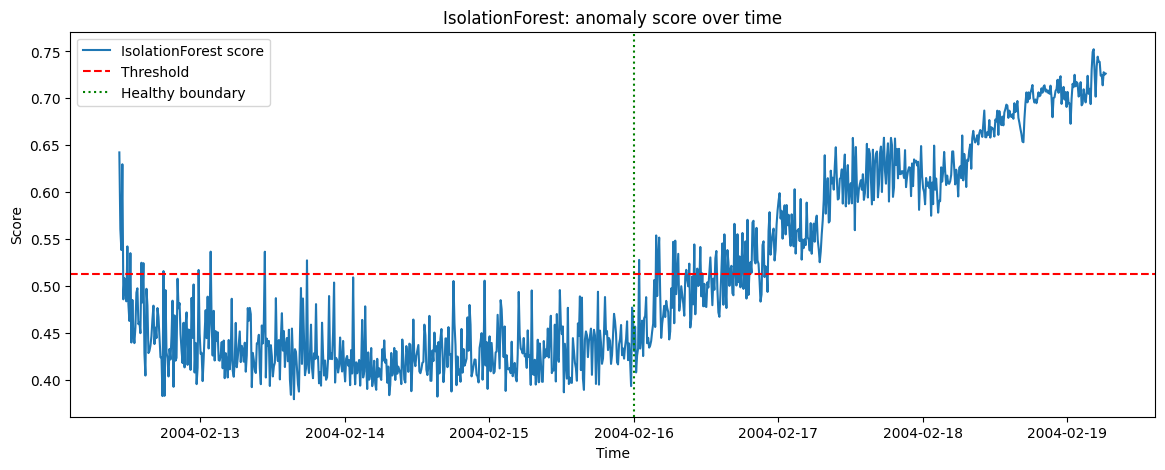

In [11]:
import matplotlib.pyplot as plt

name_to_check = "IsolationForest"
res_to_plot = classical_results[name_to_check]
scores_series, threshold = res_to_plot['scores'], res_to_plot['threshold']

plt.figure(figsize=(14, 5))
plt.plot(scores_series.index, scores_series.values, label=f"{name_to_check} score")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.axvline(HEALTHY_BOUNDARY, color="green", linestyle=":", label="Healthy boundary")
plt.legend()
plt.title(f"{name_to_check}: anomaly score over time")
plt.xlabel("Time")
plt.ylabel("Score")
plt.show()

## 12. Boundary sensitivity check

Same procedure as sections 7 and 8, repeated for boundaries shifted around
the chosen HEALTHY_BOUNDARY. The chosen boundary stays official, this only
checks how sensitive first_alarm and FPR are to that decision.

In [7]:
boundary_candidates = {
    '-12h': HEALTHY_BOUNDARY - pd.Timedelta(hours=12),
    '-6h': HEALTHY_BOUNDARY - pd.Timedelta(hours=6),
    'chosen (0h)': HEALTHY_BOUNDARY,
    '+6h': HEALTHY_BOUNDARY + pd.Timedelta(hours=6),
    '+12h': HEALTHY_BOUNDARY + pd.Timedelta(hours=12),
}
order12 = ['-12h', '-6h', 'chosen (0h)', '+6h', '+12h']

from src.experiments import boundary_sensitivity

def show_sensitivity(sdf, label):
    print(f"{label} - first confirmed alarm per boundary and model:")
    display(sdf.pivot_table(index='boundary_label', columns='model', values='alarm', aggfunc='first', observed=True))
    print(f"{label} - validation FPR per boundary and model:")
    display(sdf.pivot_table(index='boundary_label', columns='model', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))

In [8]:
from src.experiments import boundary_sensitivity

sens_df_36 = boundary_sensitivity(classical, boundary_candidates, list(df.columns), df, verbose=True)
show_sensitivity(sens_df_36, "36 features (time + spectral)")

Boundary -12h: training 4 models...


Boundary -6h: training 4 models...

Boundary chosen (0h): training 4 models...


Boundary +6h: training 4 models...


Boundary +12h: training 4 models...


36 features (time + spectral) - first confirmed alarm per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
+12h,2004-02-17 10:32:39,2004-02-17 00:12:39,NaN,2004-02-17 01:32:39
+6h,2004-02-17 10:32:39,2004-02-16 09:42:39,NaN,2004-02-16 16:42:39
-12h,2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 13:12:39
-6h,2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 13:12:39
chosen (0h),2004-02-17 01:32:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 12:32:39


36 features (time + spectral) - validation FPR per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
+12h,0.0000,0.0000,0.0000,0.0000
+6h,0.0092,0.0183,0.0000,0.0183
-12h,0.0000,0.0227,0.0000,0.0227
-6h,0.0000,0.0211,0.0000,0.0105
chosen (0h),0.0000,0.0196,0.0000,0.0098


In [9]:
from src.experiments import boundary_sensitivity

sens_df_24 = boundary_sensitivity(classical, boundary_candidates, old_cols, df, verbose=True)
show_sensitivity(sens_df_24, "24 features (time only)")

Boundary -12h: training 4 models...


Boundary -6h: training 4 models...


Boundary chosen (0h): training 4 models...


Boundary +6h: training 4 models...


Boundary +12h: training 4 models...


24 features (time only) - first confirmed alarm per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
+12h,2004-02-18 05:02:39,2004-02-16 23:22:39,NaN,2004-02-17 08:22:39
+6h,2004-02-17 10:22:39,2004-02-16 09:42:39,NaN,2004-02-17 07:02:39
-12h,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 23:22:39
-6h,2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 03:02:39
chosen (0h),2004-02-17 10:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-17 02:52:39


24 features (time only) - validation FPR per boundary and model:


model,IsolationForest,LOF,OneClassSVM,PCA
boundary_label,,,,
+12h,0.0000,0.0000,0.0000,0.0171
+6h,0.0092,0.0183,0.0000,0.0092
-12h,0.0114,0.0227,0.0114,0.0227
-6h,0.0105,0.0316,0.0211,0.0105
chosen (0h),0.0000,0.0098,0.0196,0.0196


### Reading the sensitivity check

Same 6-24 hour boundary shift, tested on both feature sets, to see whether
fragility patterns are specific to the spectral features or hold regardless.

- **OneClassSVM**: collapses (alarm = NaN) at +6h and +12h on BOTH the
  36-feature and 24-feature setups. This is not an artifact of the spectral
  features - it is a structural weakness of this model, independent of
  which features feed it.
- **LOF**: exact on the early side (-12h and -6h match chosen to the minute
  on both setups) and slips only on the late side. No sharp break, just a smooth one-sided delay.
- **IsolationForest**: stable through +6h on 24 features but breaks earlier
  (at +6h instead of +12h) once spectral features are added - the added
  features shift where the break happens, though the model never fully
  collapses like OneClassSVM.
- **PCA**: drifts on BOTH sides - on 36 features the early side holds within
  40 minutes (13:12 at -12h and -6h against 12:32 chosen) while the late side
  slides to 16:42 and then 01:32 next day. On 24 the same picture is wider,
  from 23:22 to 08:22 next day. No break anywhere, just floating in a 9 to
  12 hour band.

**Conclusion**: OneClassSVM's fragility is a property of the model itself,
confirmed on two independent feature sets - a stronger claim than relying
on one feature set alone. The chosen boundary (2004-02-16) sits in the
stable region on both setups for every model.

## 13. Scaler robustness check

Same joint setup under three scalers. Alarms stand still except PCA, which spans about 10 hours across scalers
(12:32 MinMax, 22:42 Standard, 20:32 Robust). MinMax alarms earliest here, so no
scaler dominates and the pipeline stays on MinMax until a switch is decided.

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from src.experiments import compare_scalers

order_sc = ['MinMax', 'Standard', 'Robust']
scal_df = compare_scalers(
    classical,
    {'MinMax': MinMaxScaler, 'Standard': StandardScaler, 'Robust': RobustScaler},
    df, df_healthy_train, df_healthy_val, train_end, val_end, verbose=True)
scal_df['scaler'] = pd.Categorical(scal_df['scaler'], categories=order_sc, ordered=True)
scal_df = scal_df.sort_values(['model', 'scaler']).reset_index(drop=True)
print("First confirmed alarm per scaler and model:")
display(scal_df.pivot_table(index='model', columns='scaler', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per scaler and model:")
display(scal_df.pivot_table(index='model', columns='scaler', values='fpr_val', aggfunc='first', observed=True).style.format('{:.4f}'))

Training IsolationForest (MinMax)...


Training OneClassSVM (MinMax)...

Training LOF (MinMax)...


Training PCA (MinMax)...


Training IsolationForest (Standard)...


...

Training PCA (Robust)...


First confirmed alarm per scaler and model:


scaler,MinMax,Standard,Robust
model,,,
IsolationForest,2004-02-17 01:32:39,2004-02-17 01:32:39,2004-02-17 01:32:39
LOF,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
OneClassSVM,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
PCA,2004-02-16 12:32:39,2004-02-16 22:42:39,2004-02-16 20:32:39


Validation FPR per scaler and model:


scaler,MinMax,Standard,Robust
model,,,
IsolationForest,0.0000,0.0000,0.0000
LOF,0.0196,0.0098,0.0196
OneClassSVM,0.0000,0.0000,0.0000
PCA,0.0098,0.0294,0.0196


## 14. Deep models

Same procedure as classical: train on the healthy train part only, threshold on
validation errors, alarm and FPR on the full timeline. Three dense architectures
(3 runs each) plus one LSTM autoencoder on windowed data.

In [16]:
from src.deep_models import (
    build_autoencoder, build_lstm_autoencoder, make_windows,
    run_multiple, reconstruction_error, reconstruction_error_lstm,
)

deep_results = {}
architectures = {
    'AE_1layer': [8],
    'AE_2layer': [12, 6],
    'AE_3layer': [16, 8, 4],
}
for name, hidden_layers in architectures.items():
    print(f"Training {name} (3 runs)...", flush=True)
    build_fn = lambda hl=hidden_layers: build_autoencoder(input_dim, hl)
    mean_full, _ = run_multiple(build_fn, X_healthy_train, X_all,
                                error_fn=reconstruction_error,
                                n_runs=3, epochs=50, batch_size=32)
    mean_val, _ = run_multiple(build_fn, X_healthy_train, X_healthy_val,
                               error_fn=reconstruction_error,
                               n_runs=3, epochs=50, batch_size=32)
    val_mean = float(np.mean(mean_val))
    val_std = float(np.std(mean_val))
    print(f"{name}: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
    scores_series = pd.Series(mean_full, index=df.index)
    threshold = compute_threshold(mean_val, method="mean_std", n_std=3.0)
    print(f"{name}: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
    is_anomaly = scores_series > threshold
    alarm = first_confirmed_alarm(is_anomaly, window=20)
    train_end = df_healthy_train.index[-1]
    val_end = df_healthy.index[-1]
    fpr_train = float(is_anomaly[df.index <= train_end].mean())
    fpr_val = float(is_anomaly[(df.index > train_end) & (df.index <= val_end)].mean())
    print(f"{name}: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
    print()
    deep_results[name] = {"scores": scores_series, "val_mean": val_mean, "val_std": val_std,
                          "threshold": float(threshold),
                          "alarm": alarm, "fpr_train": fpr_train, "fpr_val": fpr_val}

WINDOW_SIZE = 10
X_healthy_windows = make_windows(X_healthy_train, WINDOW_SIZE)
X_all_windows = make_windows(X_all, WINDOW_SIZE)
X_val_windows = make_windows(X_healthy_val, WINDOW_SIZE)
lstm_index = df.index[WINDOW_SIZE - 1:]
build_lstm_fn = lambda: build_lstm_autoencoder(WINDOW_SIZE, input_dim, encoding_dim=8)
lstm_full, _ = run_multiple(build_lstm_fn, X_healthy_windows, X_all_windows,
                            error_fn=reconstruction_error_lstm,
                            n_runs=3, epochs=50, batch_size=32)
lstm_val, _ = run_multiple(build_lstm_fn, X_healthy_windows, X_val_windows,
                           error_fn=reconstruction_error_lstm,
                           n_runs=3, epochs=50, batch_size=32)
val_mean = float(np.mean(lstm_val))
val_std = float(np.std(lstm_val))
print(f"LSTM_AE: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
lstm_series = pd.Series(lstm_full, index=lstm_index)
threshold = compute_threshold(lstm_val, method="mean_std", n_std=3.0)
print(f"LSTM_AE: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
is_anomaly = lstm_series > threshold
alarm = first_confirmed_alarm(is_anomaly, window=20)
lstm_mask = lstm_index <= val_end
lstm_train_end = df_healthy_train.index[-1]
fpr_train = float(is_anomaly[(lstm_index <= lstm_train_end)].mean())
fpr_val = float(is_anomaly[(lstm_index > lstm_train_end) & lstm_mask].mean())
print(f"LSTM_AE: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")
deep_results['LSTM_AE'] = {"scores": lstm_series, "val_mean": val_mean, "val_std": val_std,
                           "threshold": float(threshold),
                           "alarm": alarm, "fpr_train": fpr_train, "fpr_val": fpr_val}

Training AE_1layer (3 runs)...


AE_1layer: val_errors mean=0.02442  std=0.00851
AE_1layer: threshold = 0.02442 + 3*0.00851 = 0.04997
AE_1layer: first_alarm=2004-02-16 06:22:39  fpr_train=0.0292  fpr_val=0.0196 (primary)

Training AE_2layer (3 runs)...


AE_2layer: val_errors mean=0.02092  std=0.00753
AE_2layer: threshold = 0.02092 + 3*0.00753 = 0.04350
AE_2layer: first_alarm=2004-02-16 06:22:39  fpr_train=0.0170  fpr_val=0.0000 (primary)

Training AE_3layer (3 runs)...


AE_3layer: val_errors mean=0.02385  std=0.00858
AE_3layer: threshold = 0.02385 + 3*0.00858 = 0.04960
AE_3layer: first_alarm=2004-02-16 06:22:39  fpr_train=0.0316  fpr_val=0.0196 (primary)



LSTM_AE: val_errors mean=0.02375  std=0.00312
LSTM_AE: threshold = 0.02375 + 3*0.00312 = 0.03311
LSTM_AE: first_alarm=2004-02-16 06:32:39  fpr_train=0.0398  fpr_val=0.0000 (primary)


## 15. Deep models summary table

Same columns as the classical summary: threshold, first alarm and both FPRs.

In [17]:
deep_summary_df = pd.DataFrame([{
    'model': name,
    'val_mean': r['val_mean'],
    'val_std': r['val_std'],
    'threshold': r['threshold'],
    'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
    'fpr_train': r['fpr_train'],
    'fpr_val': r['fpr_val'],
} for name, r in deep_results.items()]).sort_values('model').reset_index(drop=True)
display(deep_summary_df.style.format({'val_mean': '{:.5f}', 'val_std': '{:.5f}',
    'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

,model,val_mean,val_std,threshold,first_alarm,fpr_train,fpr_val
0,AE_1layer,0.02442,0.00851,0.04997,2004-02-16 06:22:39,0.0292,0.0196
1,AE_2layer,0.02092,0.00753,0.04350,2004-02-16 06:22:39,0.0170,0.0000
2,AE_3layer,0.02385,0.00858,0.04960,2004-02-16 06:22:39,0.0316,0.0196
3,LSTM_AE,0.02375,0.00312,0.03311,2004-02-16 06:32:39,0.0398,0.0000


## 16. Deep score plots

Anomaly score against threshold over time for every deep model, same style
as the classical visual check.

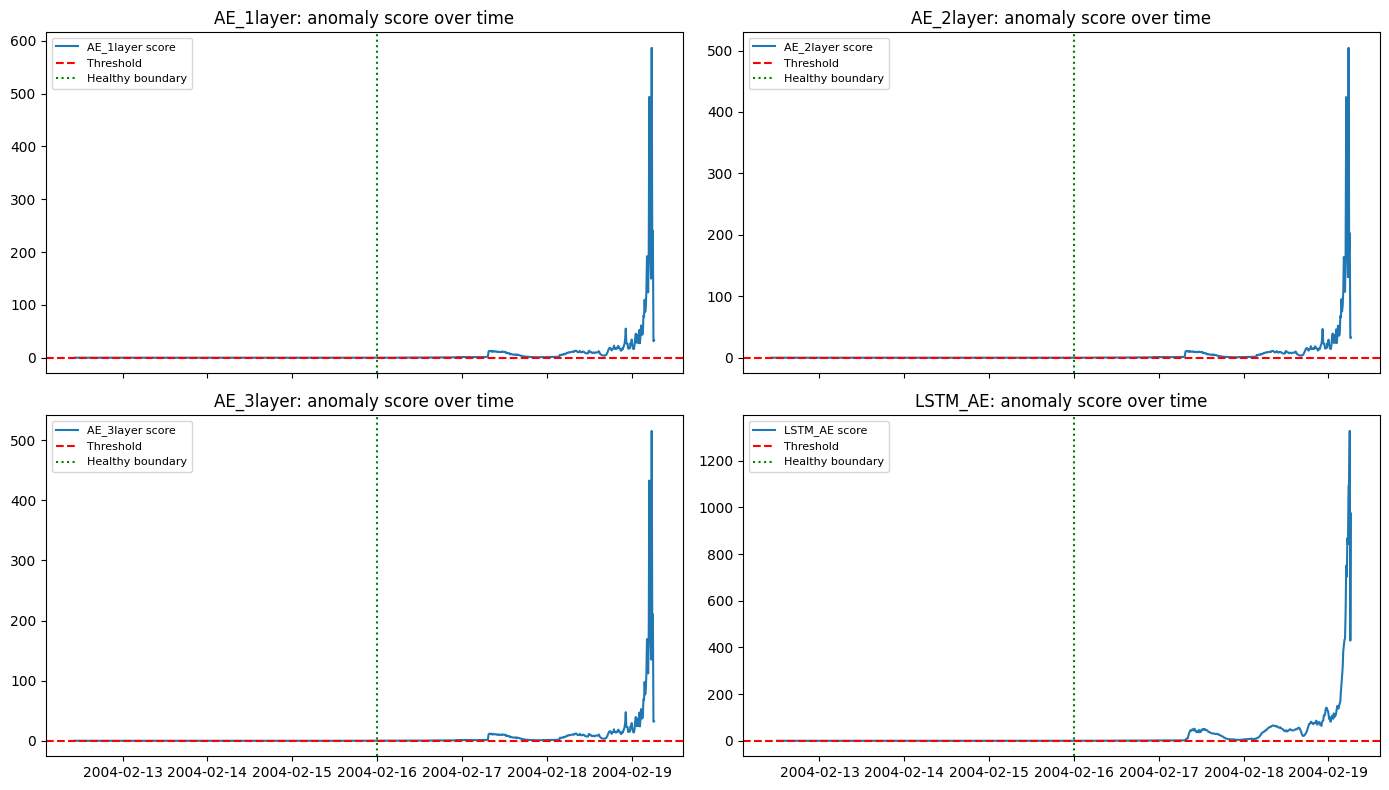

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, name in zip(axes.flat, ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']):
    s = deep_results[name]['scores']
    ax.plot(s.index, s.values, label=f"{name} score")
    ax.axhline(deep_results[name]['threshold'], color='red', linestyle='--', label='Threshold')
    ax.axvline(HEALTHY_BOUNDARY, color='green', linestyle=':', label='Healthy boundary')
    ax.set_title(f"{name}: anomaly score over time")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 17. Final comparison: all models

Four classical plus all four deep (three dense architectures plus LSTM_AE).
Same columns throughout, directly showing
whether deep models add anything over the simpler classical methods.

In [ ]:
final_rows = []
for name, r in classical_results.items():
    final_rows.append({'family': 'classical', 'model': name, 'threshold': r['threshold'],
                       'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': r['fpr_train'], 'fpr_val': r['fpr_val']})
for name in ['AE_1layer', 'AE_2layer', 'AE_3layer', 'LSTM_AE']:
    r = deep_results[name]
    final_rows.append({'family': 'deep', 'model': name, 'threshold': r['threshold'],
                       'first_alarm': (r['alarm'].strftime('%Y-%m-%d %H:%M:%S') if r['alarm'] is not None else None),
                       'fpr_train': r['fpr_train'], 'fpr_val': r['fpr_val']})
final_df = pd.DataFrame(final_rows)
display(final_df.style.format({'threshold': '{:.5f}', 'fpr_train': '{:.4f}', 'fpr_val': '{:.4f}'}))

,family,model,threshold,first_alarm,fpr_train,fpr_val
0,classical,IsolationForest,0.51331,2004-02-17 01:32:39,0.0316,0.0000
1,classical,OneClassSVM,0.16852,2004-02-16 06:22:39,0.0000,0.0000
2,classical,LOF,1.26813,2004-02-16 06:22:39,0.0195,0.0196
3,classical,PCA,0.12244,2004-02-16 12:32:39,0.0122,0.0098
4,deep,AE_1layer,0.04997,2004-02-16 06:22:39,0.0292,0.0196
5,deep,AE_2layer,0.04350,2004-02-16 06:22:39,0.0170,0.0000
6,deep,AE_3layer,0.04960,2004-02-16 06:22:39,0.0316,0.0196
7,deep,LSTM_AE,0.03311,2004-02-16 06:32:39,0.0398,0.0000


## 18. CNN on spectrograms

Same procedure on 64x64 log-magnitude frames of Bearing 1: train on healthy,
threshold on validation errors, alarm and FPR on all frames. Frames use global
normalization (healthy max only) so fault amplitude survives; per-frame
normalization erased it and gave no alarm. Three runs averaged.

In [20]:
from src.spectro import load_spectrograms, cache_path
from src.deep_models import build_cnn_autoencoder, reconstruction_error_images

X_spec, idx_spec = load_spectrograms(cache_path('data/raw/2nd_test/', 'Bearing_1', norm='global'))
X_spec = X_spec[..., None]
h_pos = np.flatnonzero(idx_spec < HEALTHY_BOUNDARY)
n_spec_val = int(len(h_pos) * 0.2)
train_pos, val_pos = h_pos[:-n_spec_val], h_pos[-n_spec_val:]
Xtr_spec, Xva_spec = X_spec[train_pos], X_spec[val_pos]
print(f"Spectrogram frames - train: {len(Xtr_spec)}, val: {len(Xva_spec)}, all: {len(X_spec)}")

build_cnn_fn = lambda: build_cnn_autoencoder(64, 64)
cnn_full, _ = run_multiple(build_cnn_fn, Xtr_spec, X_spec,
                            error_fn=reconstruction_error_images,
                            n_runs=3, epochs=30, batch_size=32)
cnn_val, _ = run_multiple(build_cnn_fn, Xtr_spec, Xva_spec,
                           error_fn=reconstruction_error_images,
                           n_runs=3, epochs=30, batch_size=32)
val_mean = float(np.mean(cnn_val))
val_std = float(np.std(cnn_val))
print(f"CNN: val_errors mean={val_mean:.5f}  std={val_std:.5f}")
cnn_series = pd.Series(cnn_full, index=idx_spec)
threshold = compute_threshold(cnn_val, method="mean_std", n_std=3.0)
print(f"CNN: threshold = {val_mean:.5f} + 3*{val_std:.5f} = {threshold:.5f}")
is_anomaly = cnn_series > threshold
alarm = first_confirmed_alarm(is_anomaly, window=20)
fpr_train = float(is_anomaly.iloc[train_pos].mean())
fpr_val = float(is_anomaly.iloc[val_pos].mean())
print(f"CNN: first_alarm={alarm}  fpr_train={fpr_train:.4f}  fpr_val={fpr_val:.4f} (primary)")

Spectrogram frames - train: 411, val: 102, all: 984


CNN: val_errors mean=0.00247  std=0.00012
CNN: threshold = 0.00247 + 3*0.00012 = 0.00285
CNN: first_alarm=2004-02-16 09:52:39  fpr_train=0.0049  fpr_val=0.0000 (primary)


## 19. Deep per feature training

All three dense architectures trained on one feature type at a time, same
procedure as section 13. Slow section, kept only to check whether deep models
rank features the same way classical ones do. LSTM per feature is skipped,
windowed training times six would be too expensive.

In [19]:
deep_feat_rows = []
for arch_name, hidden in [('AE_1layer', [8]), ('AE_2layer', [12, 6]), ('AE_3layer', [16, 8, 4])]:
    print(f"Training {arch_name} per feature...", flush=True)
    for feat in ['RMS', 'Kurtosis', 'CrestFactor', 'Peak', 'Skewness', 'Std']:
        cols = [c for c in df.columns if c.endswith('_' + feat)]
        Xtr_f, Xa_f, sc_f = scale_features(df_healthy_train[cols], df[cols])
        Xva_f = sc_f.transform(df_healthy_val[cols])
        build_f = lambda hl=hidden: build_autoencoder(4, hl)
        mean_full, _ = run_multiple(build_f, Xtr_f, Xa_f,
                                    error_fn=reconstruction_error,
                                    n_runs=3, epochs=50, batch_size=32)
        mean_val, _ = run_multiple(build_f, Xtr_f, Xva_f,
                                   error_fn=reconstruction_error,
                                   n_runs=3, epochs=50, batch_size=32)
        threshold = compute_threshold(mean_val, method="mean_std", n_std=3.0)
        s = pd.Series(mean_full, index=df.index)
        is_an = s > threshold
        alarm = first_confirmed_alarm(is_an, window=20)
        train_end = df_healthy_train.index[-1]
        val_end = df_healthy.index[-1]
        fpr_train = float(is_an[(s.index <= train_end)].mean())
        fpr_val = float(is_an[(s.index > train_end) & (s.index <= val_end)].mean())
        deep_feat_rows.append({'arch': arch_name, 'feature': feat,
                               'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                               'fpr_train': round(fpr_train, 4), 'fpr_val': round(fpr_val, 4)})
deep_feat_df = pd.DataFrame(deep_feat_rows)
display(deep_feat_df.pivot_table(index='feature', columns='arch', values='alarm', aggfunc='first', observed=True))

arch,AE_1layer,AE_2layer,AE_3layer
feature,,,
Kurtosis,2004-02-17 06:32:39,2004-02-17 01:32:39,2004-02-17 01:32:39
Peak,2004-02-17 10:12:39,2004-02-17 10:02:39,2004-02-17 10:12:39
RMS,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
Skewness,2004-02-18 12:42:39,2004-02-17 20:42:39,2004-02-18 14:02:39
Std,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39


### Reading the deep per feature table

Only RMS and Std match the joint alarm time of 16.02 06:22. The rest lag into
the next day and later: Kurtosis on 17.02 morning (01:32), Peak on 17.02 around
10:00, Skewness one to two days later depending on the model (17.02 evening through 18.02 midday), CrestFactor never. The order matches the classical per feature table exactly,
so the ranking lives in the data, not in the model. Depth does not change
the ranking, but it moves exact times for weak features: Peak shifts by 10
minutes, Kurtosis by 5 hours, Skewness by up to 16 hours across depths, while
RMS and Std alarm to the minute identically everywhere. Strong signals are
depth invariant, weak ones wobble with architecture.

## 20. Training curves: overfitting check

One model per architecture trained with history kept, plus the LSTM and the CNN.
Both curves falling and flattening together means healthy training.
Validation rising while train keeps falling would mean memorization.

AE_1layer: final train loss 0.02361, val loss 0.02458


AE_2layer: final train loss 0.01846, val loss 0.01919


AE_3layer: final train loss 0.02160, val loss 0.02056


LSTM_AE: final train loss 0.02312, val loss 0.02161


CNN: final train loss 0.00280, val loss 0.00273


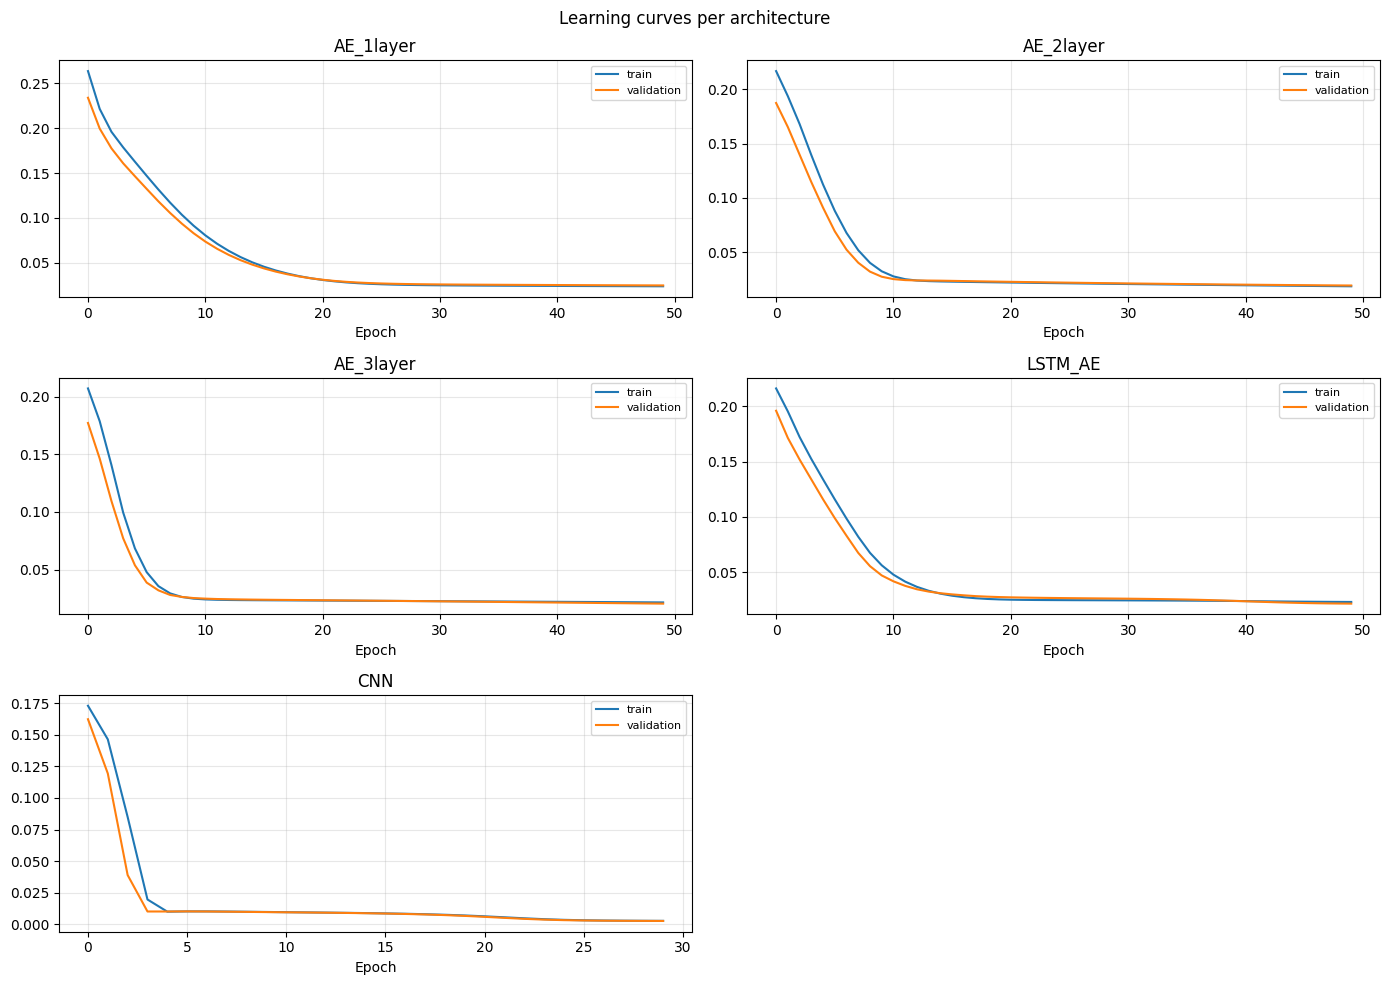

In [21]:
from src.deep_models import train_autoencoder, build_cnn_autoencoder

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, name, build, data in [
    (axes[0, 0], 'AE_1layer', lambda: build_autoencoder(input_dim, [8]), (X_healthy_train, X_healthy_val)),
    (axes[0, 1], 'AE_2layer', lambda: build_autoencoder(input_dim, [12, 6]), (X_healthy_train, X_healthy_val)),
    (axes[1, 0], 'AE_3layer', lambda: build_autoencoder(input_dim, [16, 8, 4]), (X_healthy_train, X_healthy_val)),
    (axes[1, 1], 'LSTM_AE', lambda: build_lstm_autoencoder(WINDOW_SIZE, input_dim, encoding_dim=8), (X_healthy_windows, X_val_windows)),
    (axes[2, 0], 'CNN', lambda: build_cnn_autoencoder(64, 64), (Xtr_spec, Xva_spec)),
]:
    Xtr_c, Xva_c = data
    m, hist = train_autoencoder(build(), Xtr_c, epochs=50 if name != 'CNN' else 30,
                                batch_size=32, seed=0)
    print(f"{name}: final train loss {hist.history['loss'][-1]:.5f}, val loss {hist.history['val_loss'][-1]:.5f}")
    ax.plot(hist.history['loss'], label='train')
    ax.plot(hist.history['val_loss'], label='validation')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[2, 1].axis('off')
plt.suptitle('Learning curves per architecture')
plt.tight_layout()
plt.show()

## 21. Threshold rule comparison

Same models and same validation scores, three threshold rules: mean plus 3 sigma
(used everywhere above), percentile 99.5 (robust alternative) and max times 1.5
(the old unstable rule - one noisy sample moves it for everybody). Shows why
the pipeline uses mean plus 3 sigma.

In [5]:
thr_rules = {
    'mean+3std': lambda v: compute_threshold(v, method="mean_std", n_std=3.0),
    'percentile_99.5': lambda v: compute_threshold(v, method="percentile", percentile=99.5),
    'max_x1.5': lambda v: float(np.max(v) * 1.5),
}

thr_rows = []
for name, fit_fn, score_fn in classical:
    print(f"Training {name}...", flush=True)
    model = fit_fn(X_healthy_train)
    full = pd.Series(score_fn(model, X_all), index=df.index)
    val = score_fn(model, X_healthy_val)
    for rname, rfn in thr_rules.items():
        t = rfn(val)
        is_an = full > t
        alarm = first_confirmed_alarm(is_an, window=20)
        train_end = df_healthy_train.index[-1]
        val_end = df_healthy.index[-1]
        fpr_v = float(is_an[(full.index > train_end) & (full.index <= val_end)].mean())
        thr_rows.append({'model': name, 'rule': rname, 'threshold': round(t, 5),
                         'alarm': (alarm.strftime('%Y-%m-%d %H:%M:%S') if alarm is not None else None),
                         'fpr': round(fpr_v, 4)})

thr_df = pd.DataFrame(thr_rows)
print("First confirmed alarm per model and threshold rule:")
display(thr_df.pivot_table(index='model', columns='rule', values='alarm', aggfunc='first', observed=True))
print("Validation FPR per model and threshold rule:")
display(thr_df.pivot_table(index='model', columns='rule', values='fpr', aggfunc='first', observed=True).style.format('{:.4f}'))

Training IsolationForest...


Training OneClassSVM...

Training LOF...


Training PCA...


First confirmed alarm per model and threshold rule:


rule,max_x1.5,mean+3std,percentile_99.5
model,,,
IsolationForest,NaN,2004-02-17 01:32:39,2004-02-17 01:32:39
LOF,2004-02-16 07:52:39,2004-02-16 06:22:39,2004-02-16 06:22:39
OneClassSVM,2004-02-16 06:22:39,2004-02-16 06:22:39,2004-02-16 06:22:39
PCA,2004-02-17 01:32:39,2004-02-16 12:32:39,2004-02-16 16:42:39


Validation FPR per model and threshold rule:


rule,max_x1.5,mean+3std,percentile_99.5
model,,,
IsolationForest,0.0000,0.0000,0.0098
LOF,0.0000,0.0196,0.0098
OneClassSVM,0.0000,0.0000,0.0098
PCA,0.0000,0.0098,0.0098
